  ЛЕТУЧКА 8 — Алгоритм имитации отжига (SA)
  T₀ = 50.0, α = 0.95, β = 1.0, итераций = 500

  f₁(x) = 5−24x+17x²−(11/3)x³+(1/4)x⁴
  Геометрический: x* = 5.99637, f* = 5.000066, время = 0.067 с
  Логарифмический: x* = 1.00412, f* = -5.41654, время = 0.046 с
  Сверхбыстрый: x* = 5.997958, f* = 5.000021, время = 0.064 с


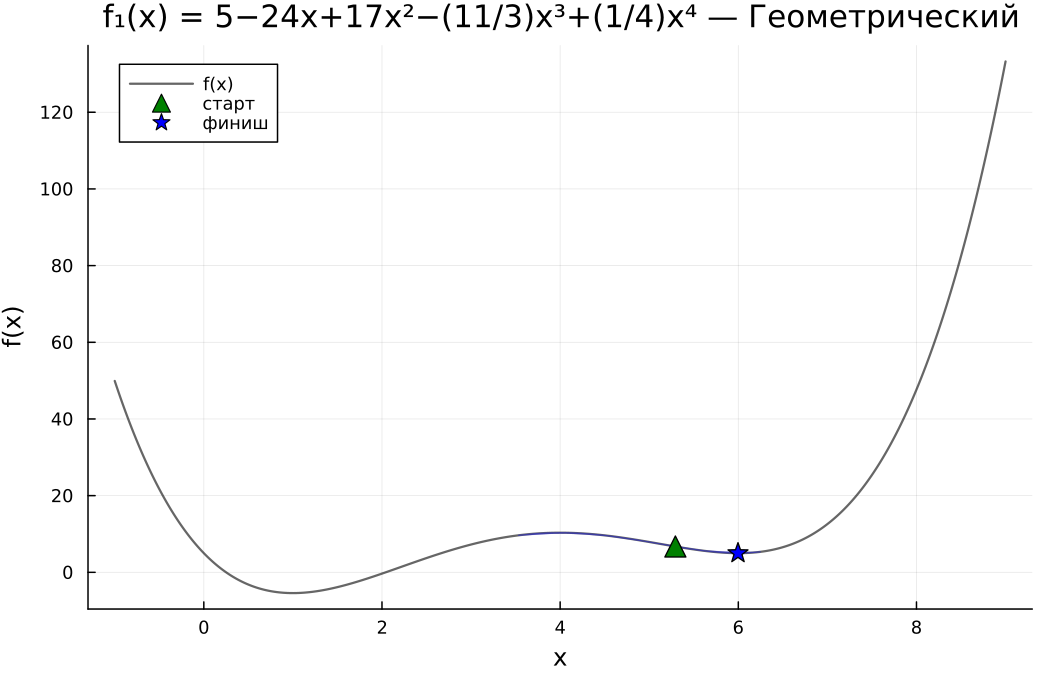

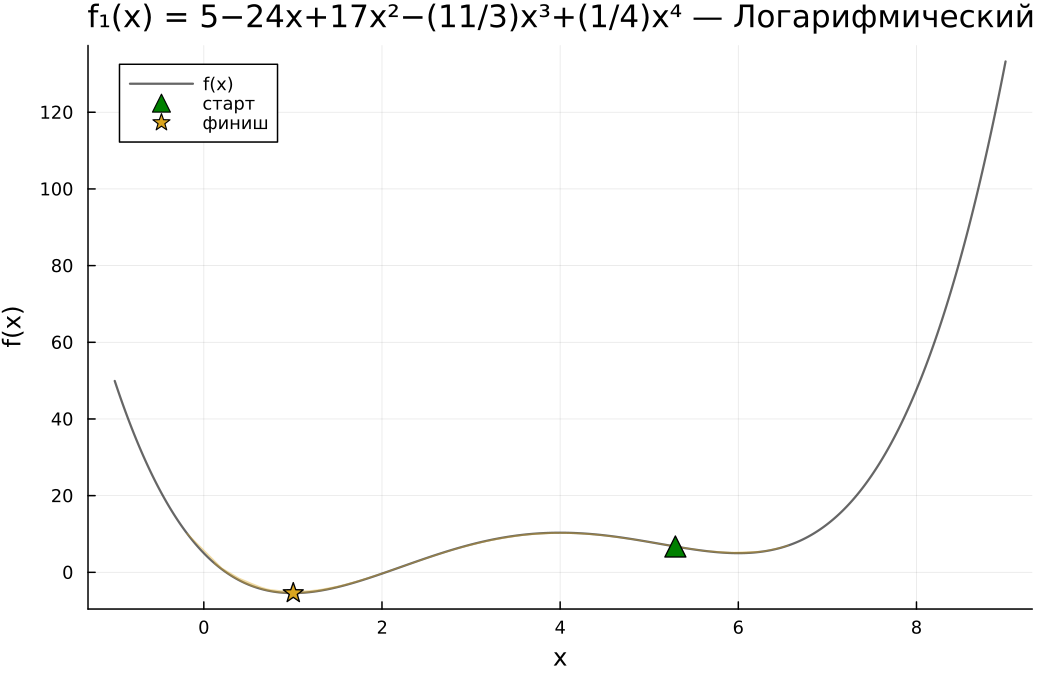

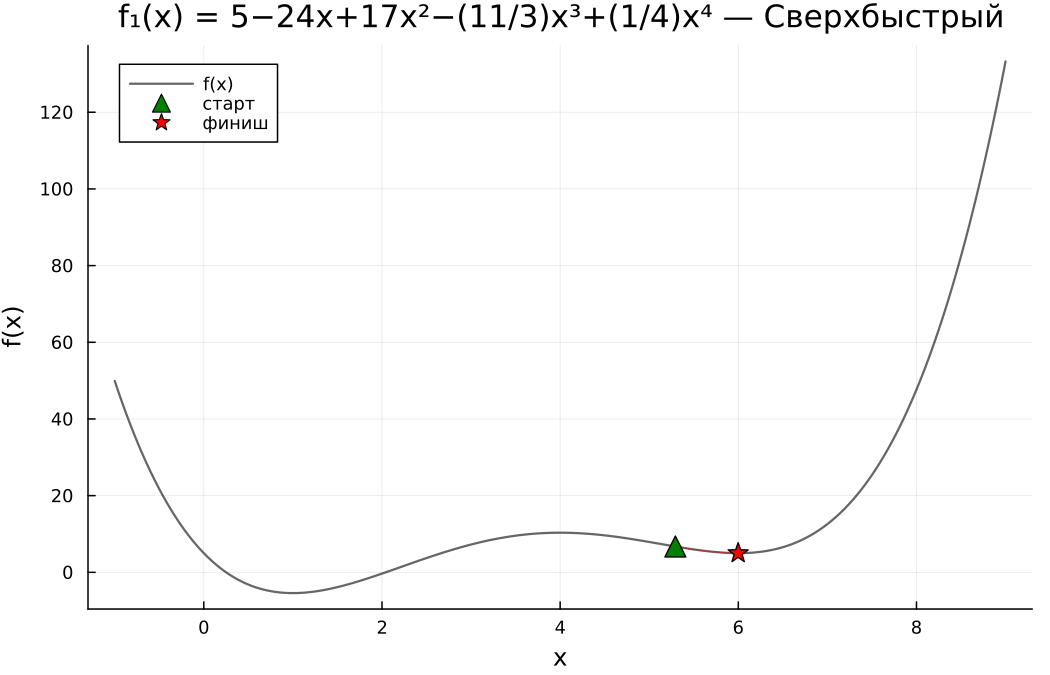

  Сохранён: f1_trajectories.png
  Сохранён: f1_convergence.png


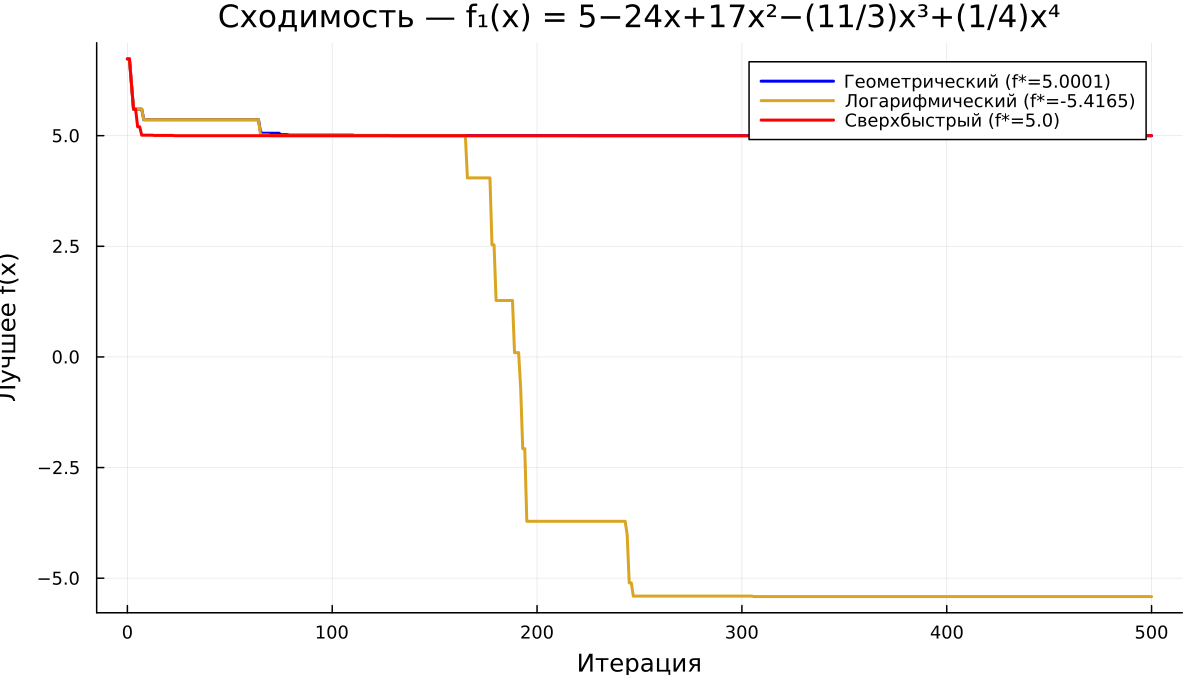

  Сохранён: f1_cooling.png


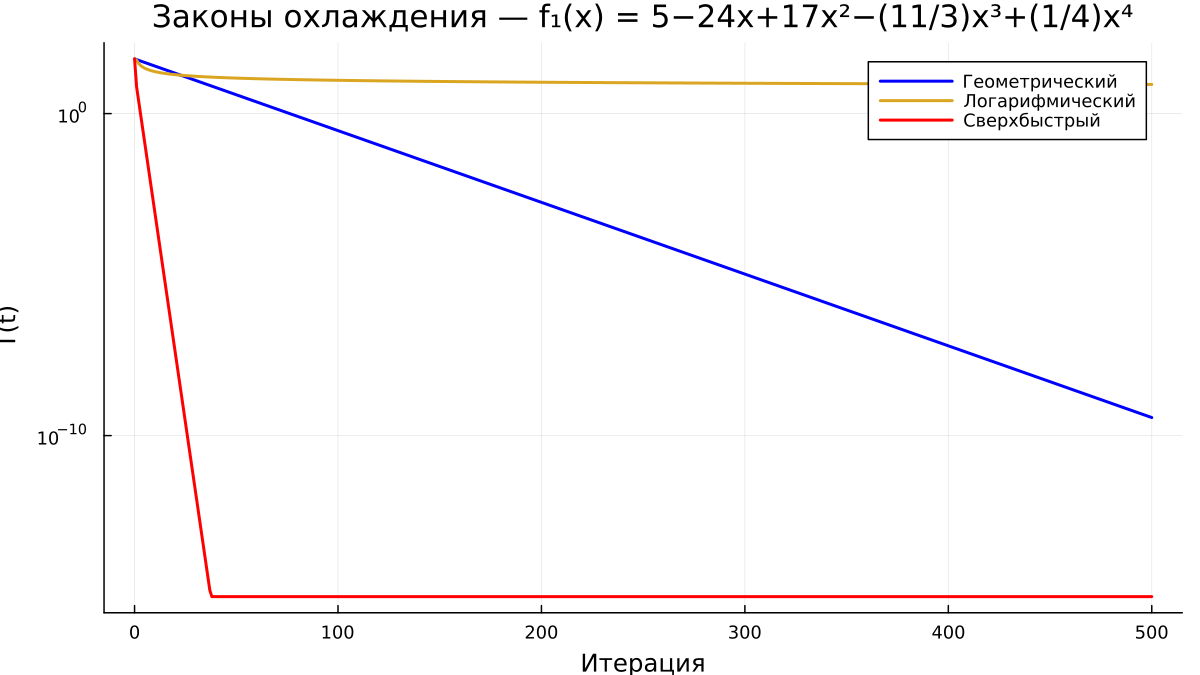

  Сохранён: letuchka8\f1_геометрический_sa.gif


[ Info: Saved animation to c:\programming\optimization-methods\letuchka8\f1_геометрический_sa.gif


  Сохранён: letuchka8\f1_логарифмический_sa.gif


[ Info: Saved animation to c:\programming\optimization-methods\letuchka8\f1_логарифмический_sa.gif


  Сохранён: letuchka8\f1_сверхбыстрый_sa.gif

  Закон охлаждения                  x*           f*   Время, с
  ---------------------------------------------------------
  Геометрический               5.99637     5.000066      0.067
  Логарифмический              1.00412     -5.41654      0.046
  Сверхбыстрый                5.997958     5.000021      0.064

  f₂(x) = x·sin(3x)+0.5x
  Геометрический: x* = 1.608839, f* = -0.793953, время = 0.043 с

[ Info: Saved animation to c:\programming\optimization-methods\letuchka8\f1_сверхбыстрый_sa.gif



  Логарифмический: x* = 5.823748, f* = -2.804321, время = 0.046 с
  Сверхбыстрый: x* = 1.604896, f* = -0.794058, время = 0.044 с


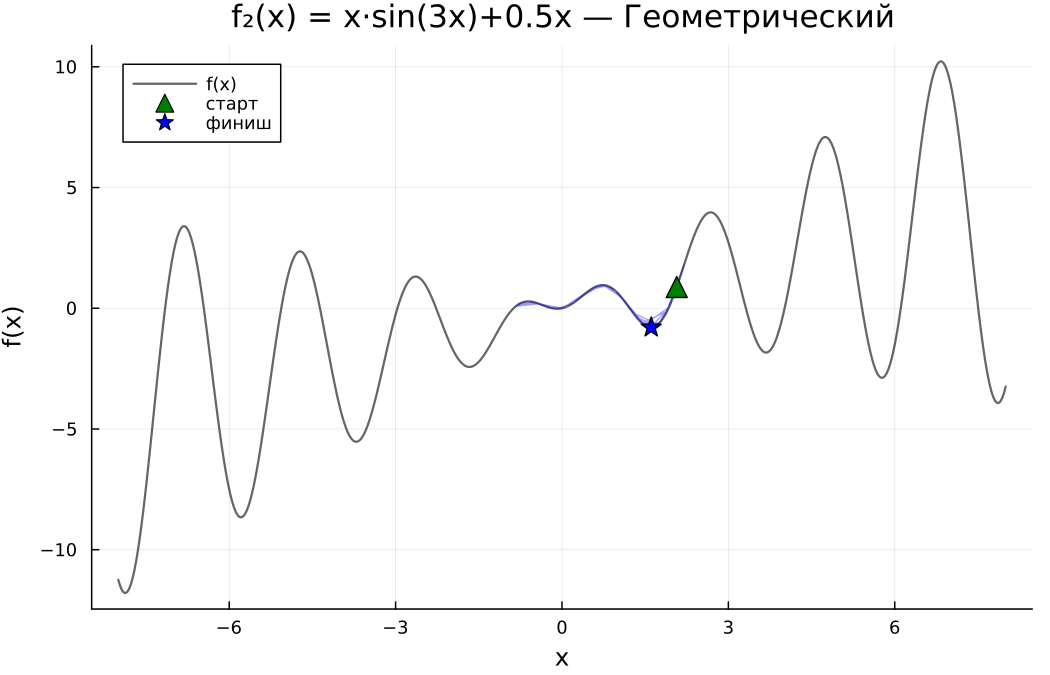

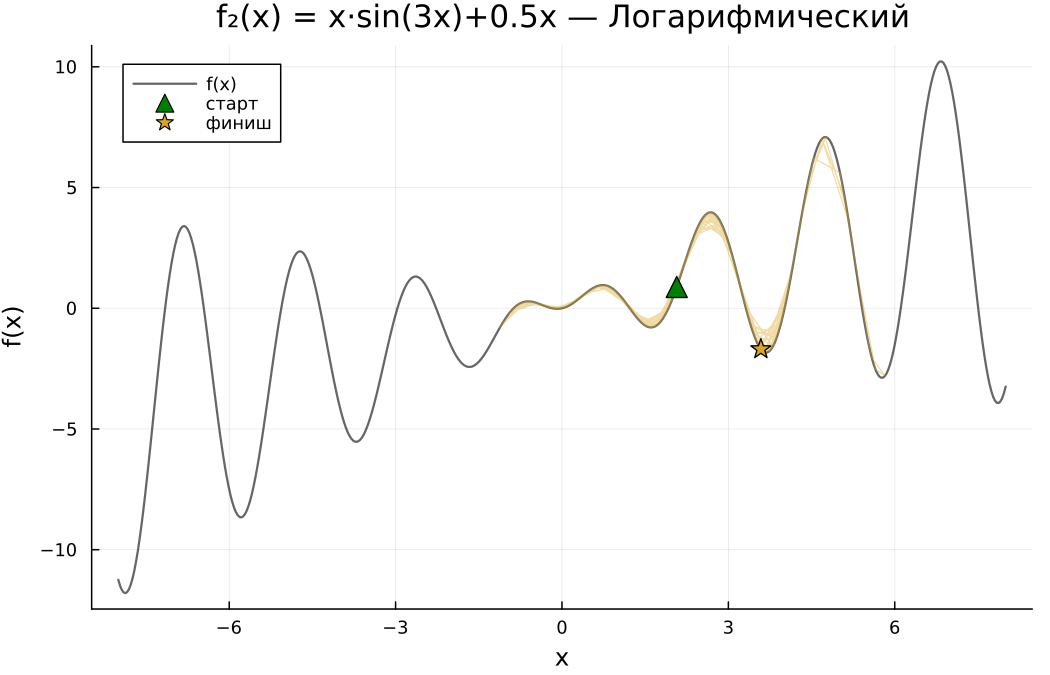

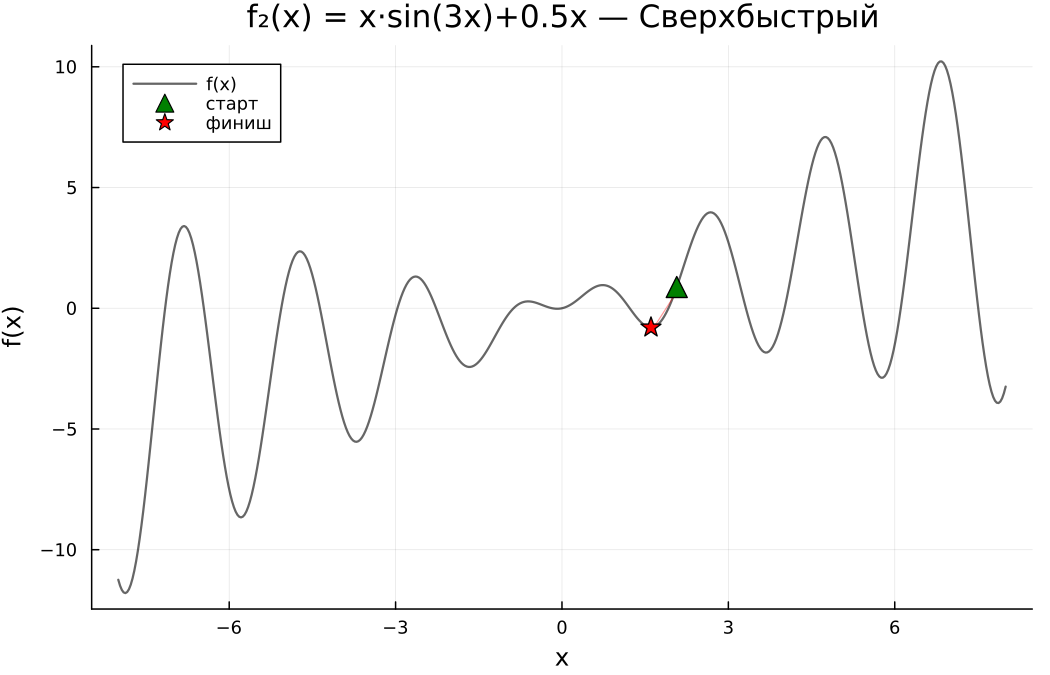

  Сохранён: f2_trajectories.png
  Сохранён: f2_convergence.png


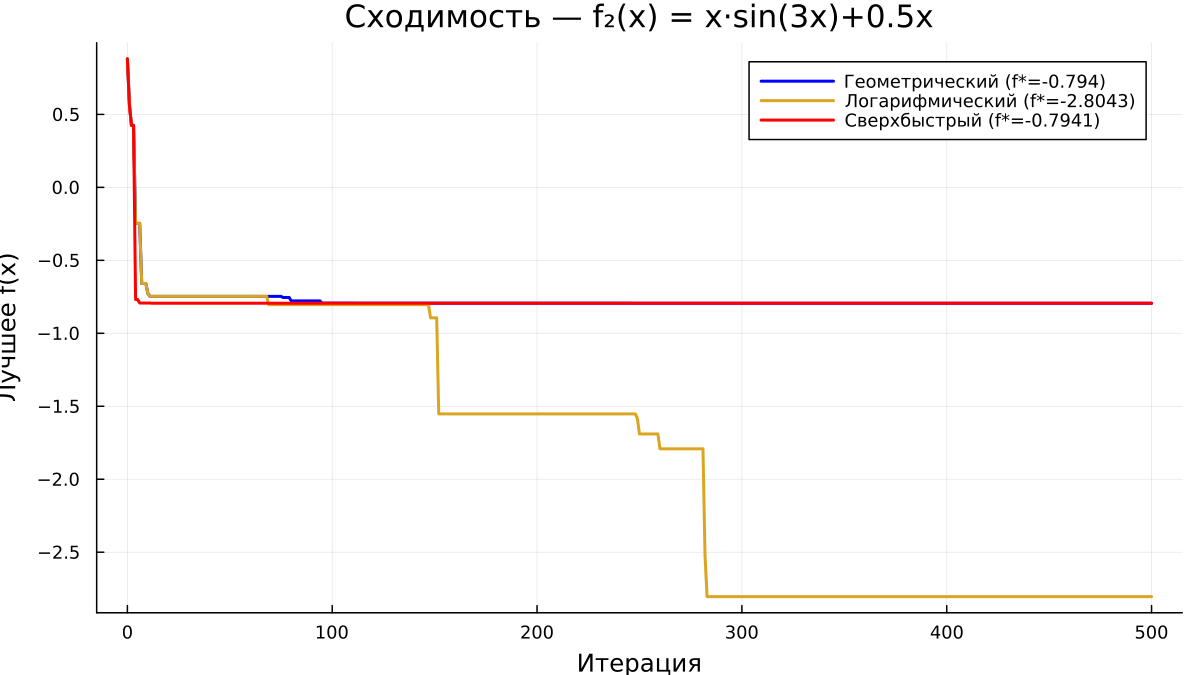

  Сохранён: f2_cooling.png


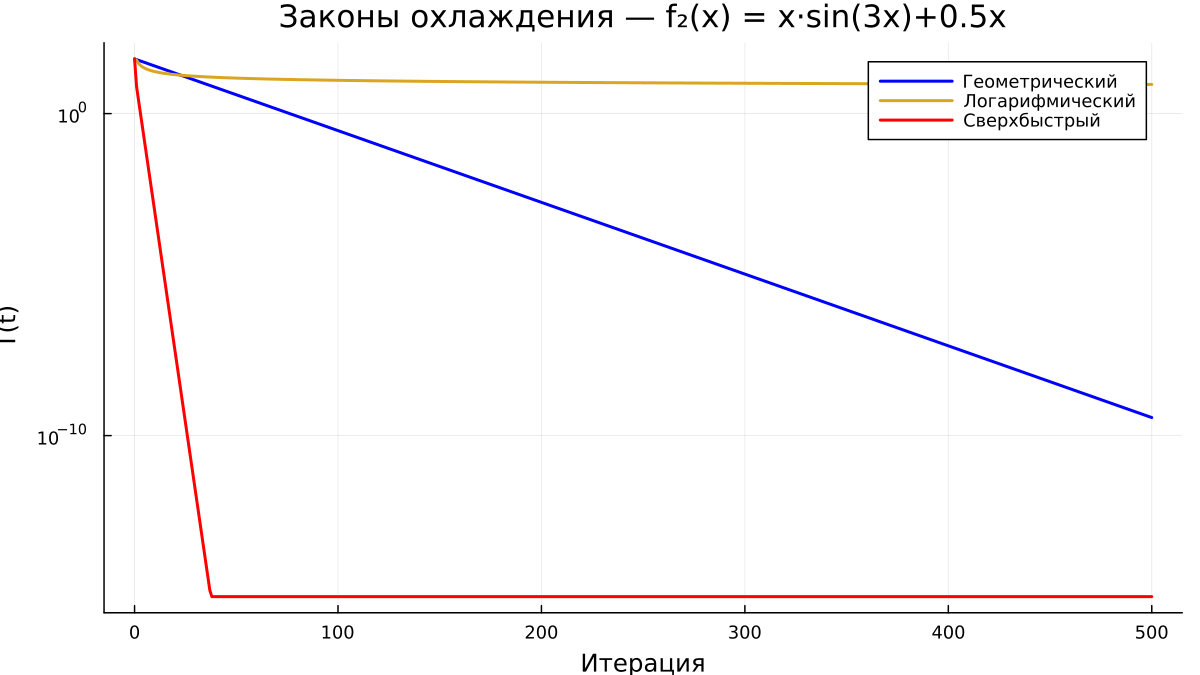

  Сохранён: letuchka8\f2_геометрический_sa.gif


[ Info: Saved animation to c:\programming\optimization-methods\letuchka8\f2_геометрический_sa.gif


  Сохранён: letuchka8\f2_логарифмический_sa.gif


[ Info: Saved animation to c:\programming\optimization-methods\letuchka8\f2_логарифмический_sa.gif


  Сохранён: letuchka8\f2_сверхбыстрый_sa.gif

  Закон охлаждения                  x*           f*   Время, с
  ---------------------------------------------------------
  Геометрический              1.608839    -0.793953      0.043
  Логарифмический             5.823748    -2.804321      0.046
  Сверхбыстрый                1.604896    -0.794058      0.044

Готово! Все файлы в letuchka8/


[ Info: Saved animation to c:\programming\optimization-methods\letuchka8\f2_сверхбыстрый_sa.gif


In [2]:
using Plots, Random

# --- конфиг ---
MAX_ITER = 500
T0 = 50.0
ALPHA = 0.95
BETA = 1.0
STEP_SIZE = 0.5
SEED = 42
SAVE_GIF = true
GIF_FPS = 6
OUTPUT_DIR = "letuchka8"

# --- тестовые функции ---

f1(x) = 5 - 24x + 17x^2 - (11/3)*x^3 + (1/4)*x^4
F1_BOUNDS = (-1.0, 9.0)

f2(x) = x * sin(3x) + 0.5x
F2_BOUNDS = (-8.0, 8.0)

# --- законы охлаждения ---

cooling_geometric(T0, t; α=ALPHA) = T0 * α^t
cooling_logarithmic(T0, t) = T0 / log(t + 2)
cooling_vfa(T0, t; β=BETA, dim=1) = T0 * exp(-β * (t+1)^(1/dim))

COOLINGS = [
    ("Геометрический",  cooling_geometric,  :blue),
    ("Логарифмический",  cooling_logarithmic, :goldenrod),
    ("Сверхбыстрый",     cooling_vfa,         :red),
]

# --- алгоритм SA ---

function simulated_annealing(func, bounds, cooling_func, T0, max_iter, step_size, seed)
    Random.seed!(seed)
    xmin, xmax = bounds

    x = xmin + rand() * (xmax - xmin)
    fx = func(x)
    best_x, best_fx = x, fx

    trajectory = [(x, fx)]
    best_history = [best_fx]
    temps = [T0]

    for t in 1:max_iter
        T = cooling_func(T0, t)
        T = max(T, 1e-15)

        x_cand = clamp(x + (rand() * 2 - 1) * step_size, xmin, xmax)
        fx_cand = func(x_cand)
        Δ = fx_cand - fx

        if Δ <= 0
            x, fx = x_cand, fx_cand
        else
            p = exp(-Δ / T)
            if rand() < p
                x, fx = x_cand, fx_cand
            end
        end

        if fx < best_fx
            best_x, best_fx = x, fx
        end

        push!(trajectory, (x, fx))
        push!(best_history, best_fx)
        push!(temps, T)
    end

    return best_x, best_fx, trajectory, best_history, temps
end

# --- визуализация ---

function plot_trajectory(func, bounds, func_name, trajectory, cooling_name, color)
    xs = range(bounds[1], bounds[2], length=500)
    ys = func.(xs)

    p = plot(xs, ys, color=:black, lw=1.5, alpha=0.6, label="f(x)",
             xlabel="x", ylabel="f(x)",
             title="$func_name — $cooling_name",
             size=(700, 450), dpi=150)

    traj_x = [t[1] for t in trajectory]
    traj_y = [t[2] for t in trajectory]
    plot!(p, traj_x, traj_y, color=color, lw=0.8, alpha=0.4, label="")
    scatter!(p, [traj_x[1]], [traj_y[1]], color=:green, ms=7, markershape=:utriangle, label="старт")
    scatter!(p, [traj_x[end]], [traj_y[end]], color=color, ms=7, markershape=:star5, label="финиш")
    return p
end

function plot_gif_frame(func, bounds, func_name, trajectory, step, total, cooling_name, color)
    xs = range(bounds[1], bounds[2], length=500)
    ys = func.(xs)

    p = plot(xs, ys, color=:black, lw=1.5, alpha=0.6, label="",
             xlabel="x", ylabel="f(x)",
             title="$func_name — $cooling_name, итерация $step/$total",
             size=(700, 450), dpi=150)

    idx_end = min(step + 1, length(trajectory))
    traj_x = [t[1] for t in trajectory[1:idx_end]]
    traj_y = [t[2] for t in trajectory[1:idx_end]]
    plot!(p, traj_x, traj_y, color=color, lw=1.0, alpha=0.5, label="")
    scatter!(p, [traj_x[1]], [traj_y[1]], color=:green, ms=7, markershape=:utriangle, label="")
    scatter!(p, [traj_x[end]], [traj_y[end]], color=color, ms=8, markershape=:circle, label="")
    return p
end

# --- запуск для одной функции ---

function process_function(func, bounds, func_name, prefix)
    mkpath(OUTPUT_DIR)
    println("\n" * "=" ^ 60)
    println("  $func_name")
    println("=" ^ 60)

    results = Dict{String, Any}()

    for (cooling_name, cooling_func, color) in COOLINGS
        t_start = time()
        best_x, best_fx, traj, bh, temps = simulated_annealing(
            func, bounds, cooling_func, T0, MAX_ITER, STEP_SIZE, SEED
        )
        elapsed = time() - t_start
        results[cooling_name] = Dict(
            "best_x" => best_x, "best_fx" => best_fx,
            "trajectory" => traj, "best_history" => bh,
            "temps" => temps, "color" => color, "time" => elapsed
        )
        println("  $cooling_name: x* = $(round(best_x, digits=6)), f* = $(round(best_fx, digits=6)), время = $(round(elapsed, digits=4)) с")
    end

    # --- траектории ---
    plots_traj = []
    for (cooling_name, _, color) in COOLINGS
        r = results[cooling_name]
        p = plot_trajectory(func, bounds, func_name, r["trajectory"], cooling_name, color)
        push!(plots_traj, p)
        display(p)
    end
    p_all = plot(plots_traj..., layout=(1,3), size=(1800, 500))
    savefig(p_all, joinpath(OUTPUT_DIR, "$(prefix)_trajectories.png"))
    println("  Сохранён: $(prefix)_trajectories.png")

    # --- сходимость ---
    p_conv = plot(title="Сходимость — $func_name",
                  xlabel="Итерация", ylabel="Лучшее f(x)",
                  size=(800, 450), dpi=150, legend=:topright)
    for (cooling_name, _, color) in COOLINGS
        r = results[cooling_name]
        bh = r["best_history"]
        plot!(p_conv, 0:length(bh)-1, bh,
              color=color, lw=2,
              label="$cooling_name (f*=$(round(r["best_fx"], digits=4)))")
    end
    savefig(p_conv, joinpath(OUTPUT_DIR, "$(prefix)_convergence.png"))
    println("  Сохранён: $(prefix)_convergence.png")
    display(p_conv)

    # --- температура ---
    p_temp = plot(title="Законы охлаждения — $func_name",
                  xlabel="Итерация", ylabel="T(t)",
                  size=(800, 450), dpi=150, legend=:topright, yscale=:log10)
    for (cooling_name, _, color) in COOLINGS
        r = results[cooling_name]
        temps = r["temps"]
        plot!(p_temp, 0:length(temps)-1, temps, color=color, lw=2, label=cooling_name)
    end
    savefig(p_temp, joinpath(OUTPUT_DIR, "$(prefix)_cooling.png"))
    println("  Сохранён: $(prefix)_cooling.png")
    display(p_temp)

    # --- GIF ---
    if SAVE_GIF
        for (cooling_name, _, color) in COOLINGS
            r = results[cooling_name]
            traj = r["trajectory"]
            n = length(traj)
            key_frames = sort(unique(vcat(
                collect(1:min(20, n)),
                collect(20:10:n),
                [n]
            )))
            anim = Animation()
            for step in key_frames
                fr = plot_gif_frame(func, bounds, func_name, traj, step, MAX_ITER, cooling_name, color)
                frame(anim, fr)
            end
            tag = lowercase(replace(cooling_name, " " => "_"))
            gp = joinpath(OUTPUT_DIR, "$(prefix)_$(tag)_sa.gif")
            gif(anim, gp, fps=GIF_FPS)
            println("  Сохранён: $gp")
        end
    end

    # --- таблица ---
    println()
    println("  $(rpad("Закон охлаждения", 25)) $(lpad("x*", 10)) $(lpad("f*", 12)) $(lpad("Время, с", 10))")
    println("  " * "-" ^ 57)
    for (cooling_name, _, _) in COOLINGS
        r = results[cooling_name]
        println("  $(rpad(cooling_name, 25)) $(lpad(string(round(r["best_x"], digits=6)), 10)) $(lpad(string(round(r["best_fx"], digits=6)), 12)) $(lpad(string(round(r["time"], digits=4)), 10))")
    end

    return results
end

# --- запуск ---

println("=" ^ 60)
println("  ЛЕТУЧКА 8 — Алгоритм имитации отжига (SA)")
println("  T₀ = $T0, α = $ALPHA, β = $BETA, итераций = $MAX_ITER")
println("=" ^ 60)

r1 = process_function(f1, F1_BOUNDS, "f₁(x) = 5−24x+17x²−(11/3)x³+(1/4)x⁴", "f1")
r2 = process_function(f2, F2_BOUNDS, "f₂(x) = x·sin(3x)+0.5x", "f2")

println("\n" * "=" ^ 60)
println("Готово! Все файлы в $OUTPUT_DIR/")
println("=" ^ 60)